# pandas

- Un outils de manipulation de tableaux remplis de données hétérogènes.

- Un peu comme faire du excel mais en python

- Il permet de manipuler de grands tableaux avec des labels pour les lignes et les colonnes.

- Très adapté aux stats.

- L'idée vient de langage R.

- DataFrame = Tableau de data 2D

- Series = colonne de data 1D



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Series = 1D

In [2]:
s = pd.Series([7, 'yep', 'yop', 20.60])
s

0       7
1     yep
2     yop
3    20.6
dtype: object

In [3]:
s = pd.Series(data=['sam', 'garcia', 75000.], index=['prenom', 'nom', 'salaire_annuel'])
s

prenom                sam
nom                garcia
salaire_annuel    75000.0
dtype: object

In [4]:
s['nom']

'garcia'

In [5]:
s['nom'] = 'Garcia'
s

prenom                sam
nom                Garcia
salaire_annuel    75000.0
dtype: object

In [6]:
s.values

array(['sam', 'Garcia', 75000.0], dtype=object)

In [7]:
s.index

Index(['prenom', 'nom', 'salaire_annuel'], dtype='str')

## Filtrage

In [8]:
d = {'OFC':10., 'PRL' : 50., 'APC' : 12.46, 'CA1': np.nan, 'DG':  20.6}
nb_cell = pd.Series(d)
print(nb_cell)

OFC    10.00
PRL    50.00
APC    12.46
CA1      NaN
DG     20.60
dtype: float64


In [9]:
nb_cell[nb_cell>15.]

PRL    50.0
DG     20.6
dtype: float64

In [10]:
over_thresh = nb_cell>15.
over_thresh

OFC    False
PRL     True
APC    False
CA1    False
DG      True
dtype: bool

In [11]:
'DG' in nb_cell

True

### C'est comme numpy : opérateurs possibles

In [12]:
square = nb_cell**2
square

OFC     100.0000
PRL    2500.0000
APC     155.2516
CA1          NaN
DG      424.3600
dtype: float64

In [13]:
zscore = (nb_cell-nb_cell.mean())/nb_cell.std()
zscore

OFC   -0.721318
PRL    1.453783
APC   -0.587549
CA1         NaN
DG    -0.144916
dtype: float64

### Missing values

In [14]:
nb_cell.isnull()

OFC    False
PRL    False
APC    False
CA1     True
DG     False
dtype: bool

In [15]:
nb_cell.notnull()

OFC     True
PRL     True
APC     True
CA1    False
DG      True
dtype: bool

In [16]:
nb_cell[nb_cell.notnull()]

OFC    10.00
PRL    50.00
APC    12.46
DG     20.60
dtype: float64

# DataFrame = 2D

- C'est un tableau avec chaque colonne = une Series



In [17]:
data = {
    'name':['alex', 'sam', 'jules'],
    'sex' : [ 'F', 'M', 'M'],
    'alcohol_consumption' : [False, True, True],
    'drug_consumption' : [True, np.nan,  False],
    'coding_level' : [ 83.5, 100., 60.3],
}

formateur = pd.DataFrame(data, columns=['name', 'sex', 'alcohol_consumption', 'drug_consumption', 'coding_level'])
formateur


,name,sex,alcohol_consumption,drug_consumption,coding_level
0,alex,F,False,True,83.5
1,sam,M,True,NaN,100.0
2,jules,M,True,False,60.3


- index plus explicite

In [18]:
formateur.index = ['ac', 'sg',  'jg']
formateur

,name,sex,alcohol_consumption,drug_consumption,coding_level
ac,alex,F,False,True,83.5
sg,sam,M,True,NaN,100.0
jg,jules,M,True,False,60.3


## Inspection

In [19]:
formateur.info()

<class 'pandas.DataFrame'>
Index: 3 entries, ac to jg
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 3 non-null      str    
 1   sex                  3 non-null      str    
 2   alcohol_consumption  3 non-null      bool   
 3   drug_consumption     2 non-null      object 
 4   coding_level         3 non-null      float64
dtypes: bool(1), float64(1), object(1), str(2)
memory usage: 231.0+ bytes


In [20]:
formateur.dtypes

name                       str
sex                        str
alcohol_consumption       bool
drug_consumption        object
coding_level           float64
dtype: object

In [21]:
formateur.columns

Index(['name', 'sex', 'alcohol_consumption', 'drug_consumption',
       'coding_level'],
      dtype='str')

In [22]:
formateur.index

Index(['ac', 'sg', 'jg'], dtype='str')

In [23]:
formateur.describe()

,coding_level
count,3.000000
mean,81.266667
std,19.944005
min,60.300000
25%,71.900000
50%,83.500000
75%,91.750000
max,100.000000


## Sélectionner une colonne

- par dict ou attribut

In [24]:
print(formateur['name']) # dict method

ac     alex
sg      sam
jg    jules
Name: name, dtype: str


In [25]:
print(type(formateur['name'])) # # dict method

<class 'pandas.Series'>


In [26]:
print(formateur.name) # attribute method

ac     alex
sg      sam
jg    jules
Name: name, dtype: str


In [27]:
print(type(formateur.name)) # attribute method

<class 'pandas.Series'>


## Sélectionner plusieurs colonnes

In [28]:
col_selection_list = ['alcohol_consumption', 'drug_consumption']
formateur[col_selection_list]


,alcohol_consumption,drug_consumption
ac,False,True
sg,True,NaN
jg,True,False


## La vraie syntaxe pour sélectionner des valeurs dans un dataframe : DataFrame.loc[]

In [29]:
# colonne
formateur.loc[:, ['alcohol_consumption', 'drug_consumption']]

,alcohol_consumption,drug_consumption
ac,False,True
sg,True,NaN
jg,True,False


In [30]:
# ligne
formateur.loc[['sg', 'jg'], :]

,name,sex,alcohol_consumption,drug_consumption,coding_level
sg,sam,M,True,NaN,100.0
jg,jules,M,True,False,60.3


In [31]:
formateur.loc[['sg', 'jg'], ['alcohol_consumption', 'drug_consumption']]

,alcohol_consumption,drug_consumption
sg,True,NaN
jg,True,False


## Syntaxe pour sélectionner par compteur : DataFrame.iloc[]

- C'est comme numpy en 2D !!!

In [32]:
formateur

,name,sex,alcohol_consumption,drug_consumption,coding_level
ac,alex,F,False,True,83.5
sg,sam,M,True,NaN,100.0
jg,jules,M,True,False,60.3


In [33]:
# colonne
formateur.loc[:, ['alcohol_consumption', 'drug_consumption']]
formateur.iloc[:, 2:4]


,alcohol_consumption,drug_consumption
ac,False,True
sg,True,NaN
jg,True,False


In [34]:
# ligne
formateur.iloc[::2, :]

,name,sex,alcohol_consumption,drug_consumption,coding_level
ac,alex,F,False,True,83.5
jg,jules,M,True,False,60.3


In [35]:
formateur.iloc[::2, 2:4]

,alcohol_consumption,drug_consumption
ac,False,True
jg,True,False


## Sélectionner par condition





In [36]:
formateur

,name,sex,alcohol_consumption,drug_consumption,coding_level
ac,alex,F,False,True,83.5
sg,sam,M,True,NaN,100.0
jg,jules,M,True,False,60.3


In [37]:
mask = formateur['coding_level'] > 80.
f = formateur[mask]
f
#f = formateur[formateur.coding_level>80.]
#f

,name,sex,alcohol_consumption,drug_consumption,coding_level
ac,alex,F,False,True,83.5
sg,sam,M,True,NaN,100.0


In [38]:
f = formateur[formateur['alcohol_consumption']]
f

,name,sex,alcohol_consumption,drug_consumption,coding_level
sg,sam,M,True,NaN,100.0
jg,jules,M,True,False,60.3


In [39]:
f = formateur[formateur.drug_consumption.isnull()]
f

,name,sex,alcohol_consumption,drug_consumption,coding_level
sg,sam,M,True,NaN,100.0


# Lecture depuis fichier : XLS, CSV, (database, clipboard, ...)

http://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html

http://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_excel.html#pandas.read_excel


In [41]:
data = pd.read_csv('./data/dataset_titanic.csv', sep=',',header=0, encoding='utf8')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [43]:
data = pd.read_excel('./data/dataset_titanic.xlsx', sheet_name='train')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [44]:
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [46]:
#data = data.set_index('PassengerId')
data.set_index('PassengerId', inplace=True)
data.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Export vers excel

In [47]:
data = {
    'name':['alex', 'sam', 'jg'],
    'sex' : [ 'F', 'M', 'M'],
    'alcohol_consumption' : [False, True, True],
    'drug_consumption' : [True, np.nan,  False],
    'coding_level' : [ 73.5,100., 19.3,],
}

formateur = pd.DataFrame(data, columns=['name', 'sex', 'alcohol_consumption', 'drug_consumption', 'coding_level'])
formateur

,name,sex,alcohol_consumption,drug_consumption,coding_level
0,alex,F,False,True,73.5
1,sam,M,True,NaN,100.0
2,jg,M,True,False,19.3


In [48]:
formateur2 = formateur[['sex', 'alcohol_consumption', 'drug_consumption', 'coding_level']]
formateur2

,sex,alcohol_consumption,drug_consumption,coding_level
0,F,False,True,73.5
1,M,True,NaN,100.0
2,M,True,False,19.3


In [49]:
with pd.ExcelWriter('formateurs.xlsx') as writer:
    formateur.to_excel(writer, sheet_name='avec nom')
    formateur2.to_excel(writer, sheet_name='anonyme')


# Export vers hdf5

In [50]:
with pd.HDFStore('allmydata.h5', mode='w') as store:
    store['/formateur'] = formateur
    store['/formateur2'] = formateur2

<positron-console-cell-50>:2: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['drug_consumption'], dtype='str')]

<positron-console-cell-50>:3: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['drug_consumption'], dtype='str')]



# Groupby

![](img/groupby.png)

Source: Gratuitously borrowed from Hadley Wickham's Data Science in R slides


In [51]:
# from pandas_datareader  import wb
# indicator = ['NY.GDP.PCAP.KD', 'IT.MOB.COV.ZS']
# data = wb.download(indicator=indicator, country='all', start=2005, end=2011) #.dropna()
# data.columns = ['gdp', 'cellphone']
# data.reset_index(inplace=True)
# data.to_excel('data/country_gpd_cellphone.xlsx')

In [53]:
data = pd.read_excel('data/country_gpd_cellphone.xlsx', index_col = 0)
data

,country,year,gdp,cellphone
0,Arab World,2011,5990.917180,NaN
1,Arab World,2010,5918.315891,NaN
2,Arab World,2009,5785.710406,NaN
3,Arab World,2008,5899.879787,NaN
4,Arab World,2007,5715.905696,NaN
...,...,...,...,...
2263,Zimbabwe,2009,NaN,41.0
2264,Zimbabwe,2008,NaN,75.0
2265,Zimbabwe,2007,NaN,75.0
2266,Zimbabwe,2006,NaN,72.0


In [54]:
data.describe()

,year,gdp,cellphone
count,2268.000000,1723.000000,268.000000
mean,2008.000000,13919.384647,75.483866
std,2.000441,20785.957137,22.743860
min,2005.000000,219.356176,0.770000
25%,2006.000000,1511.673572,64.727344
50%,2008.000000,4896.824441,82.031818
75%,2010.000000,15916.717842,92.000000
max,2011.000000,167533.014031,100.000000


In [55]:
grouped = data.groupby('country')
grouped

In [56]:
mgdp = grouped['gdp'].mean()
mgdp

country
Afghanistan             450.211465
Africa                         NaN
Albania                3688.555942
Algeria                4379.981433
American Samoa        10434.520937
                          ...     
West Bank and Gaza     2324.032021
World                  9360.358033
Yemen, Rep.            1223.659096
Zambia                 1301.682887
Zimbabwe                827.062108
Name: gdp, Length: 272, dtype: float64

In [57]:
grouped['cellphone'].mean()

country
Afghanistan                 NaN
Africa                77.130678
Albania                     NaN
Algeria               62.206667
American Samoa              NaN
                        ...    
West Bank and Gaza          NaN
World                       NaN
Yemen, Rep.                 NaN
Zambia                73.714286
Zimbabwe              66.628571
Name: cellphone, Length: 272, dtype: float64

In [58]:
columns = ['gdp', 'cellphone']
m = data.groupby('year')[columns].mean()
m

,gdp,cellphone
year,,
2005,13273.537972,59.556061
2006,13740.458838,64.030260
2007,14188.598077,76.937460
2008,14228.389774,83.960847
2009,13573.980534,84.852044
2010,14408.068075,86.360078
2011,14013.346972,84.913455


# Sort values

In [59]:
mgdp = grouped['gdp'].mean()

In [60]:
mgdp.sort_values()

country
Burundi                                                  226.668003
Ethiopia                                                 296.049404
Congo, Dem. Rep.                                         321.357677
Niger                                                    337.627811
Sierra Leone                                             381.335776
                                                            ...    
Sub-Saharan Africa excluding South Africa                       NaN
Sub-Saharan Africa excluding South Africa and Nigeria           NaN
Swaziland                                                       NaN
Syrian Arab Republic                                            NaN
Turks and Caicos Islands                                        NaN
Name: gdp, Length: 272, dtype: float64

In [61]:
mgdp.sort_values(ascending = False)

country
Monaco                                                   152500.558592
Liechtenstein                                            141165.082857
Luxembourg                                               105577.083517
Bermuda                                                   90299.109894
Norway                                                    89203.941095
                                                             ...      
Sub-Saharan Africa excluding South Africa                          NaN
Sub-Saharan Africa excluding South Africa and Nigeria              NaN
Swaziland                                                          NaN
Syrian Arab Republic                                               NaN
Turks and Caicos Islands                                           NaN
Name: gdp, Length: 272, dtype: float64

In [62]:
mgdp.sort_values(ascending = False).dropna()

country
Monaco              152500.558592
Liechtenstein       141165.082857
Luxembourg          105577.083517
Bermuda              90299.109894
Norway               89203.941095
                        ...      
Sierra Leone           381.335776
Niger                  337.627811
Congo, Dem. Rep.       321.357677
Ethiopia               296.049404
Burundi                226.668003
Name: gdp, Length: 249, dtype: float64

# Plot directly from pandas

<Axes: xlabel='year'>

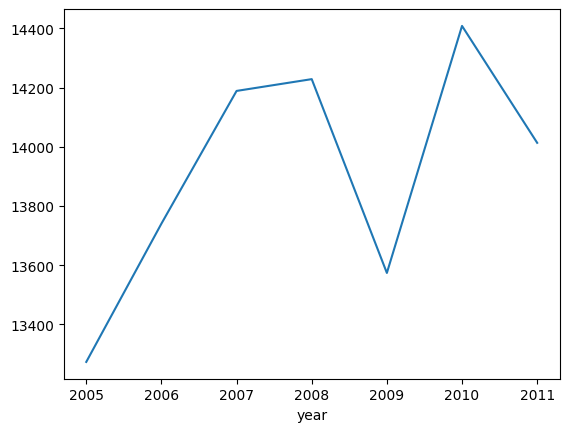

In [63]:
m['gdp'].plot()

<Axes: ylabel='Frequency'>

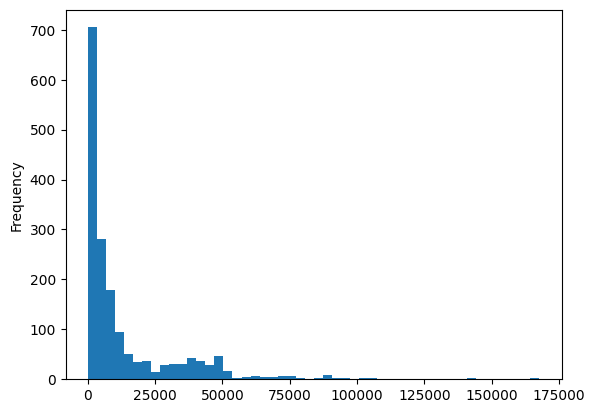

In [64]:
data['gdp'].plot.hist(bins=50)

# Stack / Unstack et multindex

In [65]:
# Création du multiindex
data2 = data.iloc[:200][['country', 'year', 'gdp', ]]
data2.set_index(['country','year'], inplace=True)
data2


gdp
country                    year             
Arab World                 2011  5990.917180
                           2010  5918.315891
                           2009  5785.710406
                           2008  5899.879787
                           2007  5715.905696
...                                      ...
Lower middle income        2005  1318.673372
Middle East & North Africa 2011  7234.311308
                           2010  7126.771934
                           2009  6933.149464
                           2008  7046.009046

[200 rows x 1 columns]

In [66]:
data3 = data2.unstack('year')
data3

#data3.loc['Arab World', ('gdp', 2005)]

gdp  \
year                                                        2005   
country                                                            
Arab World                                           5384.848325   
Caribbean small states                               8566.189483   
Central Europe and the Baltics                      10703.528188   
Early-demographic dividend                           2526.189304   
East Asia & Pacific                                  6295.724615   
East Asia & Pacific (IDA & IBRD countries)           2638.839441   
East Asia & Pacific (excluding high income)          2610.674116   
Euro area                                           36845.650760   
Europe & Central Asia                               22471.426398   
Europe & Central Asia (IDA & IBRD countries)         6920.679077   
Europe & Central Asia (excluding high income)        6556.835974   
European Union                                      32752.171572   
Fragile and conflict affected situations             1273.515405   
Heavily indebted poor countries (HIPC)                652.977319   
High income                                         37523.142446   
IBRD only                                            3491.927552   
IDA & IBRD total                                     2905.991821   
IDA blend                                            1329.118177   
IDA only                                              670.446173   
IDA total                                             892.515158   
Late-demographic dividend                            4551.004483   
Latin America & Caribbean                            7955.172321   
Latin America & Caribbean (excluding high income)    7592.878953   
Latin America & the Caribbean (IDA & IBRD count...   7852.028845   
Least developed countries: UN classification          636.063528   
Low & middle income                                  2764.487617   
Low income                                            559.228275   
Lower middle income                                  1318.673372   
Middle East & North Africa                                   NaN   

                                                                  \
year                                                        2006   
country                                                            
Arab World                                           5601.023733   
Caribbean small states                               9089.439105   
Central Europe and the Baltics                      11436.079083   
Early-demographic dividend                           2643.236636   
East Asia & Pacific                                  6596.032678   
East Asia & Pacific (IDA & IBRD countries)           2900.723729   
East Asia & Pacific (excluding high income)          2869.772319   
Euro area                                           37861.104040   
Europe & Central Asia                               23284.684684   
Europe & Central Asia (IDA & IBRD countries)         7453.854606   
Europe & Central Asia (excluding high income)        7080.925626   
European Union                                      33722.533998   
Fragile and conflict affected situations             1325.833121   
Heavily indebted poor countries (HIPC)                673.166020   
High income                                         38371.066390   
IBRD only                                            3732.618610   
IDA & IBRD total                                     3093.991500   
IDA blend                                            1377.113531   
IDA only                                              698.138406   
IDA total                                             926.760514   
Late-demographic dividend                            4917.846340   
Latin America & Caribbean                            8268.717574   
Latin America & Caribbean (excluding high income)    7877.654253   
Latin America & the Caribbean (IDA & IBRD count...   8166.087692   
Least developed countries: UN classification    

# merge/concat/alignement

- pd.concat permet de concatener des tableaux

- Attention pandas aligne tout seul data en fonction des l'index.
- Il remplit tout seul les missing values dans le cas où les labels de l'axe de concaténation sont différents


In [67]:
m1 = pd.DataFrame(np.arange(15).reshape(5,3), columns=['a', 'b', 'c'], index=[12., 12.8, 14.2, 21.2, 4.])
display(m1)
m2 = pd.DataFrame(np.arange(9).reshape(3,3), columns=['b', 'c', 'd'], index=[15., 23., 18.3])
display(m2)

,a,b,c
12.0,0,1,2
12.8,3,4,5
14.2,6,7,8
21.2,9,10,11
4.0,12,13,14


,b,c,d
15.0,0,1,2
23.0,3,4,5
18.3,6,7,8


In [68]:
a = pd.concat([m1,m2], axis=0)
a

,a,b,c,d
12.0,0.0,1,2,NaN
12.8,3.0,4,5,NaN
14.2,6.0,7,8,NaN
21.2,9.0,10,11,NaN
4.0,12.0,13,14,NaN
15.0,NaN,0,1,2.0
23.0,NaN,3,4,5.0
18.3,NaN,6,7,8.0
